In [3462]:
# 1. Pull BTC spot price and volume data

import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

load_dotenv()

url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

params = {
    "vs_currency": "usd",
    "days": 365,
    "interval": "daily"
}

response = requests.get(url, params=params)

response.raise_for_status()

data = response.json()

In [3463]:
prices_raw = pd.DataFrame(
    data['prices'],
    columns=['timestamp', 'price']
)

prices = prices_raw.copy()

prices['datetime'] = pd.to_datetime(
    prices['timestamp'],
    unit='ms',
    utc=True
)

prices['date'] = prices['datetime'].dt.normalize()

In [3464]:
prices = prices[
    prices['datetime'].dt.time
    == pd.Timestamp('00:00:00').time()
].copy()

In [3465]:
# Set date index
prices = prices.set_index('date')

# Ensure daily series is contiguous
assert (
    prices.index.to_series().diff().dropna()
    == pd.Timedelta(days=1)
).all(), "Missing dates detected in price series"

In [3466]:
prices['daily_return'] = prices['price'].pct_change().fillna(0)
prices['7d_return'] = prices['price'].pct_change(7)
prices['30d_return'] = prices['price'].pct_change(30)

In [3467]:
print(prices[['price', 'daily_return', '7d_return']].tail(10))

                                  price  daily_return  7d_return
date                                                            
2026-05-26 00:00:00+00:00  77274.401522      0.003718   0.004187
2026-05-27 00:00:00+00:00  75824.063325     -0.018769  -0.012821
2026-05-28 00:00:00+00:00  74352.699280     -0.019405  -0.040114
2026-05-29 00:00:00+00:00  73539.841896     -0.010932  -0.051666
2026-05-30 00:00:00+00:00  73382.718314     -0.002137  -0.027818
2026-05-31 00:00:00+00:00  73751.067873      0.005020  -0.038106
2026-06-01 00:00:00+00:00  73593.371197     -0.002138  -0.044095
2026-06-02 00:00:00+00:00  71360.325213     -0.030343  -0.076533
2026-06-03 00:00:00+00:00  66649.855619     -0.066010  -0.120993
2026-06-04 00:00:00+00:00  64021.889159     -0.039429  -0.138943


In [3468]:
prices['rolling_vol_7d'] = prices['daily_return'].rolling(7).std()

In [3469]:
prices['ma_7'] = prices['price'].rolling(7).mean()
prices['ma_30'] = prices['price'].rolling(30).mean()

In [3470]:
prices['signal'] = 'Neutral'

prices.loc[prices['7d_return'] > 0.05, 'signal'] = 'Strong Momentum'
prices.loc[prices['7d_return'] < -0.05, 'signal'] = 'Weak Momentum'

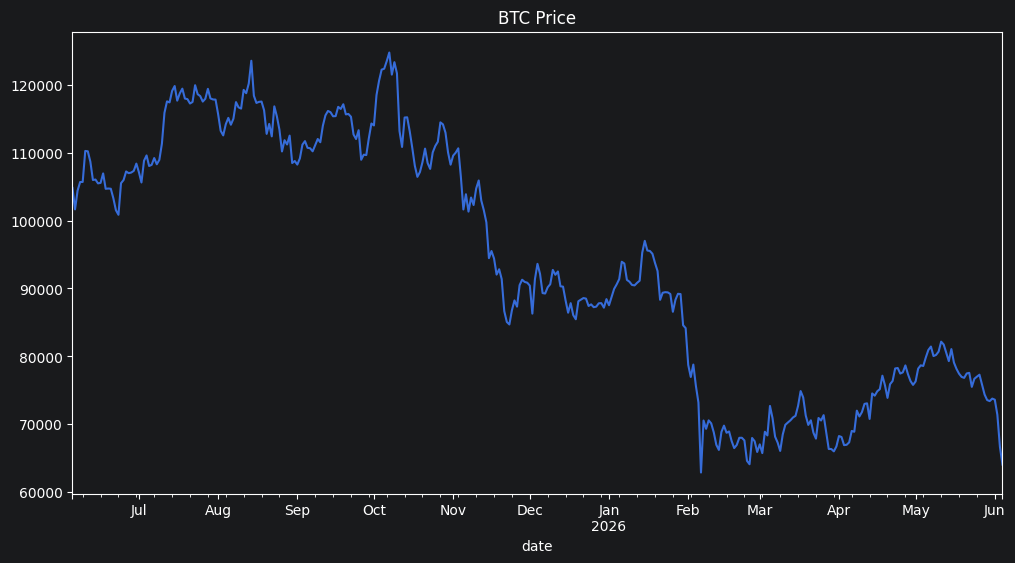

In [3471]:
prices['price'].plot(figsize=(12,6))
plt.title('BTC Price')
plt.show()

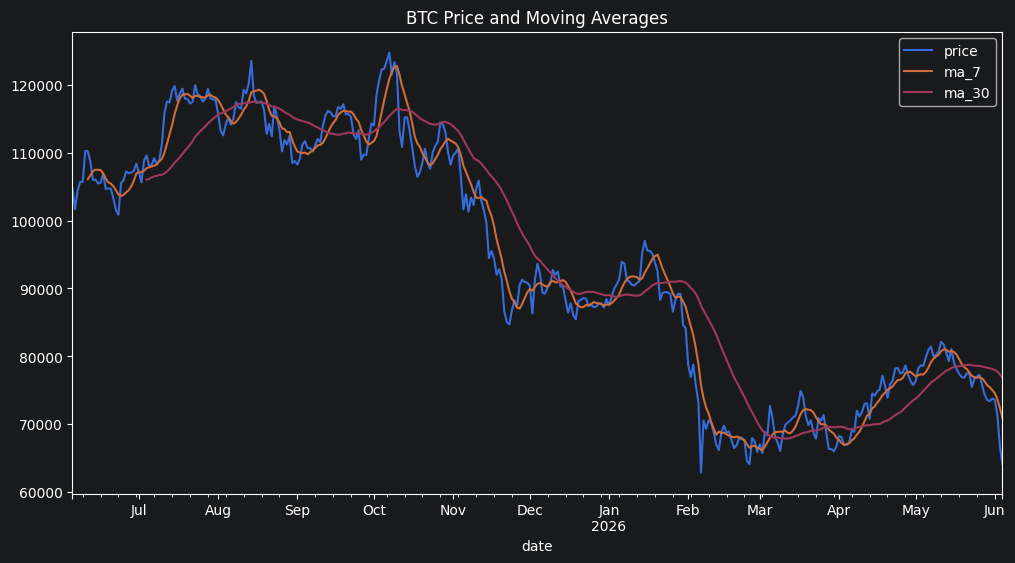

In [3472]:
prices[['price','ma_7', 'ma_30']].plot(figsize=(12,6))
plt.title('BTC Price and Moving Averages')
plt.show()

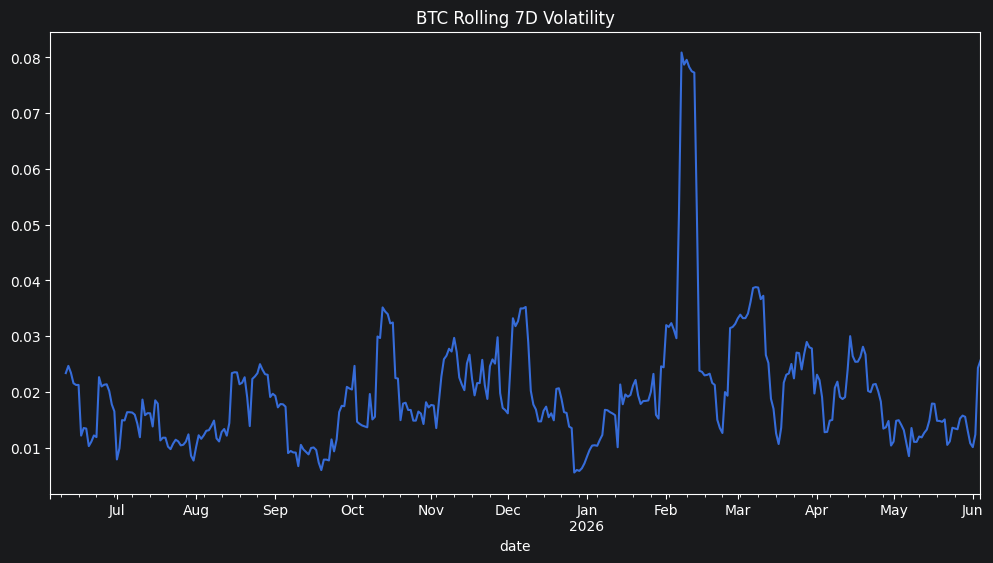

In [3473]:
prices['rolling_vol_7d'].plot(figsize=(12,6))
plt.title('BTC Rolling 7D Volatility')
plt.show()

In [3474]:
volumes_raw = pd.DataFrame(
    data['total_volumes'],
    columns=['timestamp', 'volume']
)

volumes = volumes_raw.copy()

volumes['datetime'] = pd.to_datetime(
    volumes['timestamp'],
    unit='ms',
    utc=True
)

volumes = volumes[
    volumes['datetime'].dt.time == pd.Timestamp('00:00:00').time()
].copy()

volumes['date'] = volumes['datetime'].dt.normalize()

volumes = volumes[['date', 'volume']]

In [3475]:
prices = prices.merge(volumes, on='date', how='left', validate='one_to_one')
prices = prices.set_index('date')

In [3476]:
prices['volumes_ma_7'] = prices['volume'].rolling(7).mean()

In [3477]:
prices['volume_signal'] = 'normal'

prices.loc[
    prices['volume'] > prices['volumes_ma_7']*1.5,
    'volume_signal'
] = 'Elevated Activity'

In [3478]:
volume_mean = prices['volume'].rolling(30).mean()
volume_std = prices['volume'].rolling(30).std()
prices['volume_zscore'] = (prices['volume'] - volume_mean) / volume_std

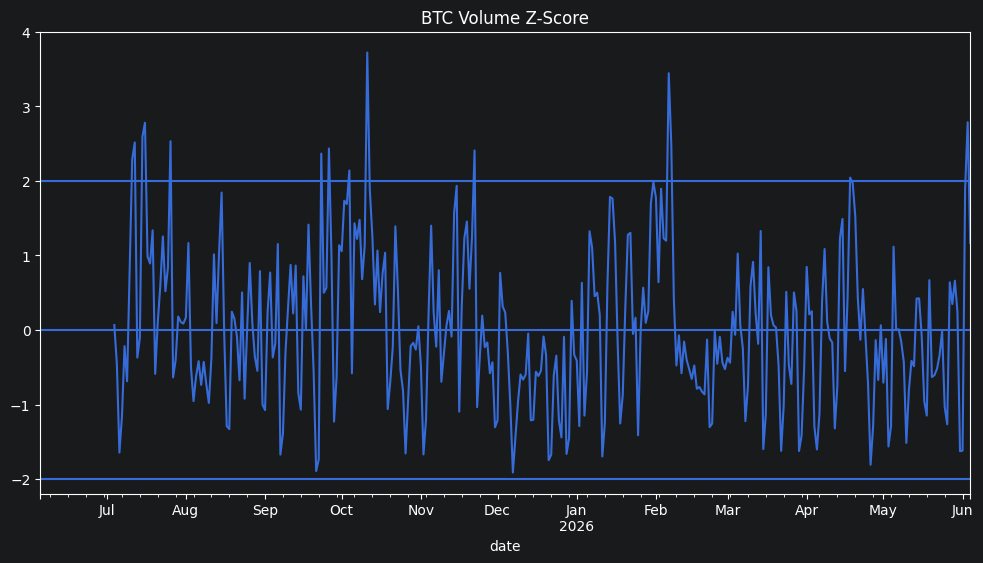

In [3479]:
prices['volume_zscore'].plot(figsize=(12,6))
plt.axhline(0)
plt.axhline(2)
plt.axhline(-2)
plt.title('BTC Volume Z-Score')
plt.show()

In [3480]:
# Create spot participation signals

prices['spot_participation_signal'] = 'Neutral'

prices.loc[
    (prices['7d_return'] > 0.05) &
     (prices['volume_zscore'] > 1),
    'spot_participation_signal'
] = 'Strong Spot Participation'

prices.loc[
    (prices['7d_return'] < -0.05) &
    (prices['volume_zscore'] > 1),
    'spot_participation_signal'
] = 'High-Volume Selloff'

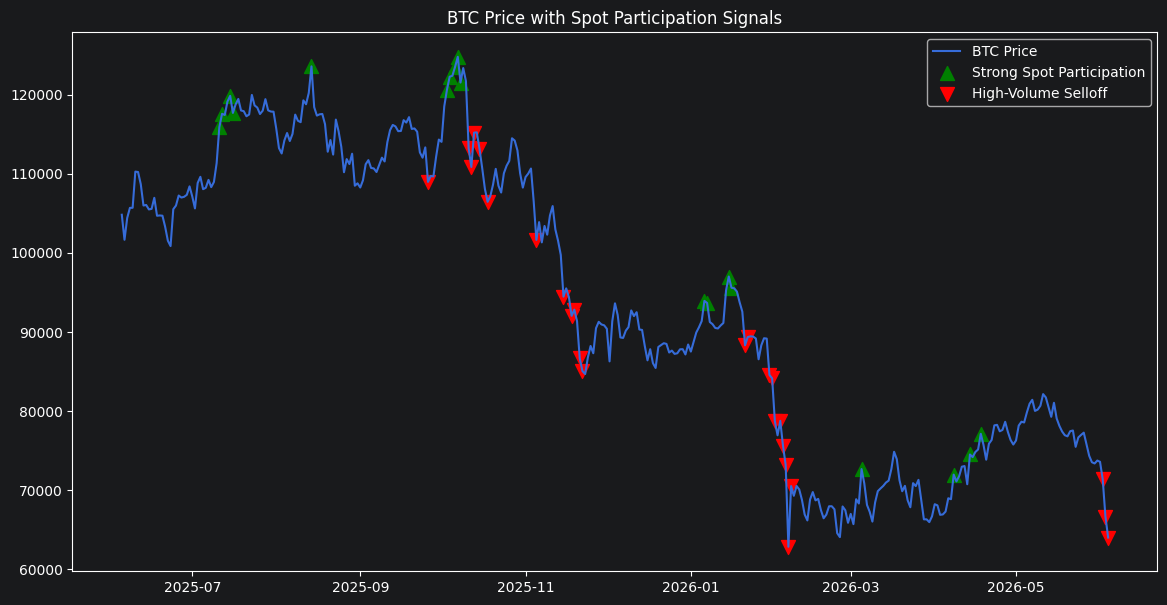

In [3481]:
strong_spot_participation = prices[prices['spot_participation_signal'] == 'Strong Spot Participation']
high_volume_selloff = prices[prices['spot_participation_signal'] == 'High-Volume Selloff']

plt.figure(figsize=(14,7))

plt.plot(prices.index,
    prices['price'],
    label='BTC Price'
)

plt.scatter(strong_spot_participation.index, strong_spot_participation['price'], label = 'Strong Spot Participation', marker = '^', color = 'green', s = 100)

plt.scatter(high_volume_selloff.index, high_volume_selloff['price'], label = 'High-Volume Selloff', marker = 'v', color = 'red', s = 100)

plt.title('BTC Price with Spot Participation Signals')
plt.legend()
plt.show()

In [3482]:
# 2. Pull BTC funding rates

hl_url = "https://api.hyperliquid.xyz/info"

end_time = int(time.time() * 1000)
start_time = end_time - (365 * 24 * 60 * 60 * 1000)

all_funding_data = []
current_start = start_time

while current_start < end_time:
    payload = {
        "type": "fundingHistory",
        "coin": "BTC",
        "startTime": current_start,
        "endTime": end_time
    }

    response = requests.post(hl_url, json=payload)
    response.raise_for_status()

    batch = response.json()

    if len(batch) == 0:
        break

    all_funding_data.extend(batch)

    last_time = batch[-1]['time']
    current_start = last_time + 1

    time.sleep(0.5)

In [3483]:
funding_raw = pd.DataFrame(all_funding_data)
funding = funding_raw.copy()

funding['time'] = pd.to_datetime(
    funding['time'],
    unit='ms',
    utc=True
)

funding['fundingRate'] = pd.to_numeric(funding['fundingRate'])

funding = funding.rename(columns={
    'time':'date',
    'fundingRate':'funding_rate'
})

funding = funding[['date', 'funding_rate']]

funding = funding.set_index('date')

daily_funding = funding.resample('D').mean()

In [3484]:
prices = prices.merge(daily_funding, on='date', how='left', validate='one_to_one')

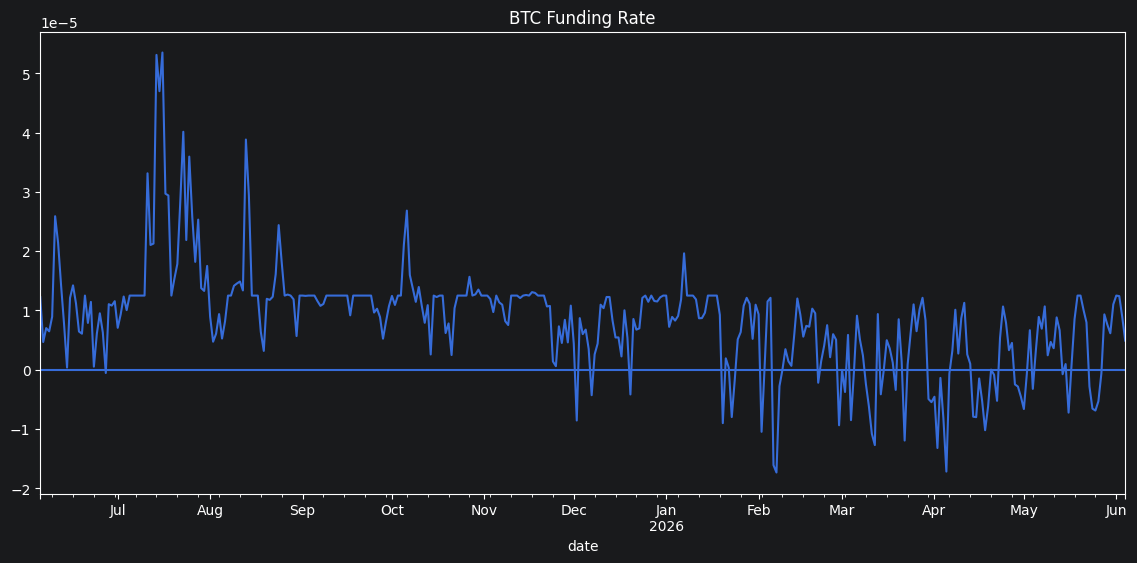

In [3485]:
prices['funding_rate'].plot(figsize=(14,6))
plt.axhline(0)
plt.title('BTC Funding Rate')
plt.show()

In [3486]:
prices['funding_ma_7d'] = prices['funding_rate'].rolling(7).mean()

Text(0.5, 1.0, 'BTC 7D Average Funding')

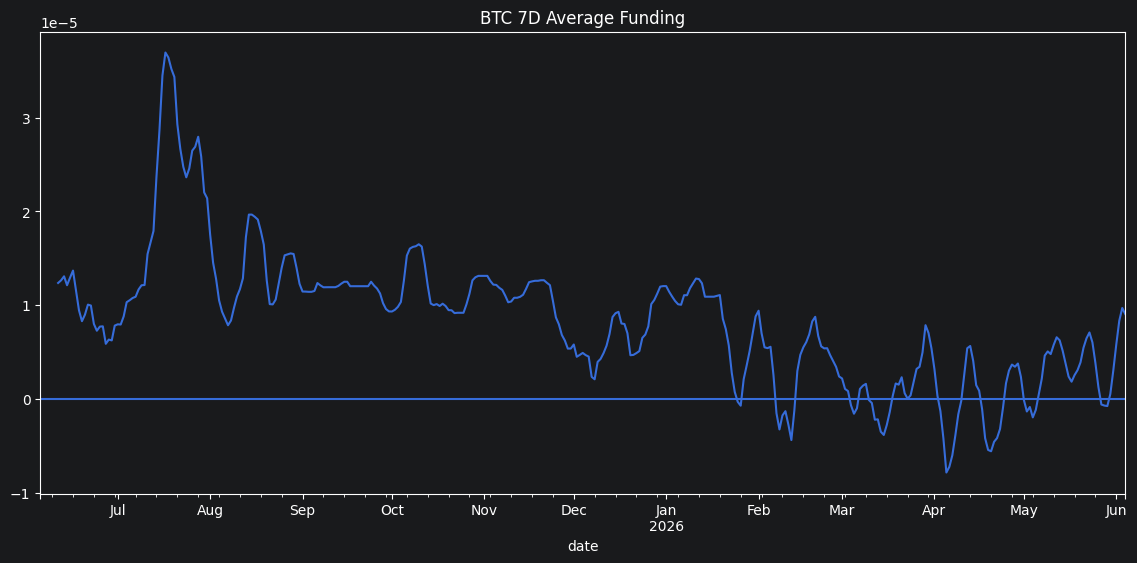

In [3487]:
prices['funding_ma_7d'].plot(figsize=(14,6))
plt.axhline(0)
plt.title('BTC 7D Average Funding')

In [3488]:
funding_mean = prices['funding_rate'].rolling(30).mean()
funding_std = prices['funding_rate'].rolling(30).std()
prices['funding_zscore'] = (prices['funding_rate'] - funding_mean) / funding_std

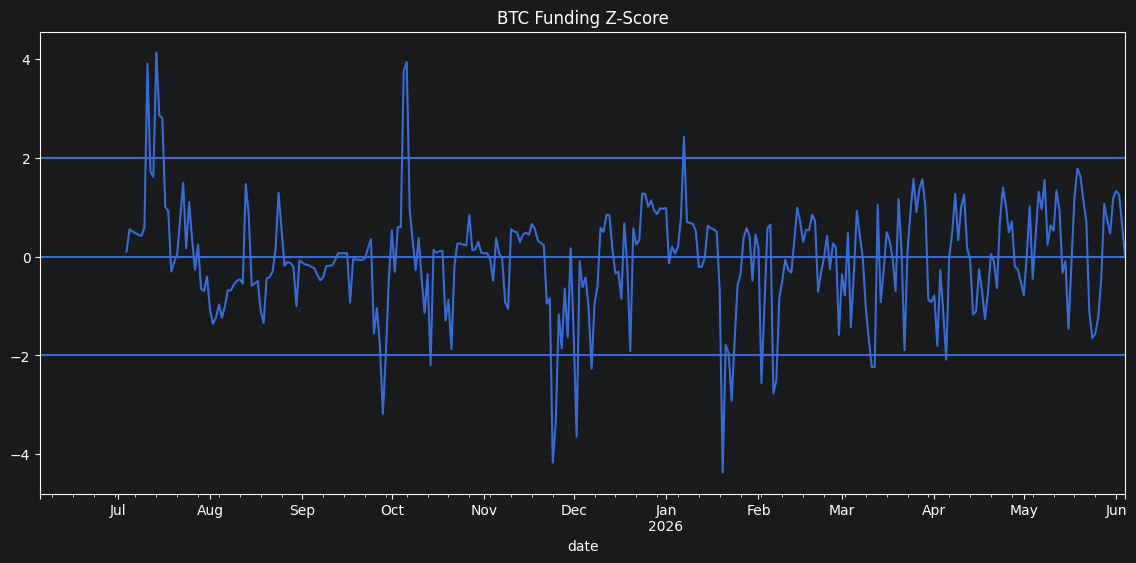

In [3489]:
prices['funding_zscore'].plot(figsize=(14,6))
plt.axhline(0)
plt.axhline(2)
plt.axhline(-2)
plt.title('BTC Funding Z-Score')
plt.show()

In [3490]:
# Create Funding/Leverage Signals

prices['funding_signal'] = 'Neutral'

prices.loc[
    prices['funding_zscore'] > 2,
    'funding_signal'
] = 'Crowded Longs'

prices.loc[
    prices['funding_zscore'] < -2,
    'funding_signal'
] = 'Crowded Shorts'

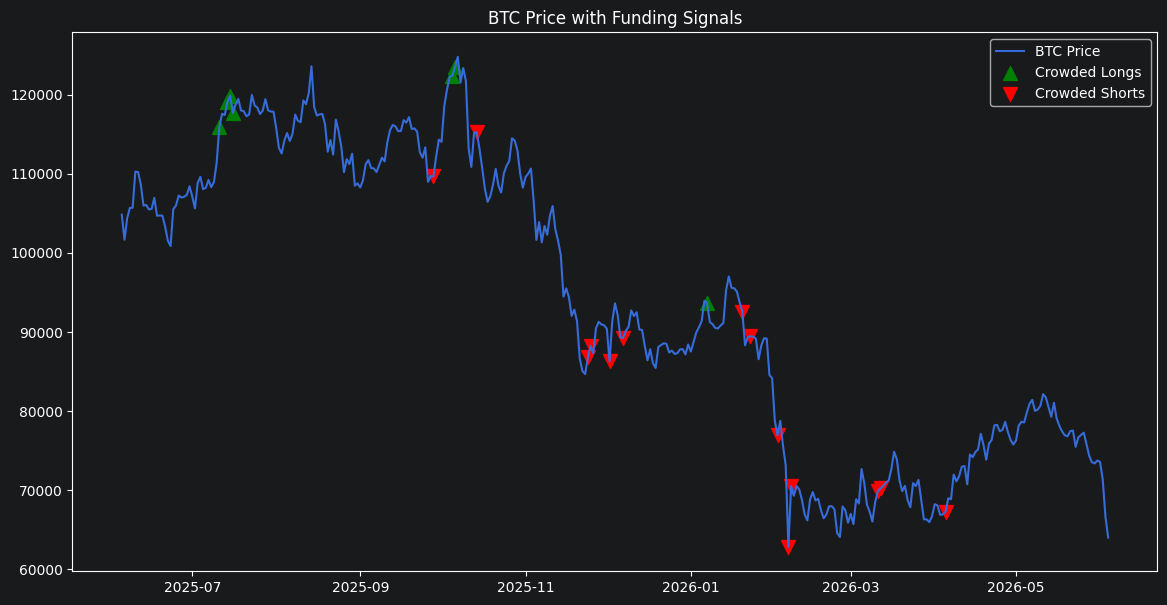

In [3491]:
# BTC Price with Funding Positioning Signals

crowded_longs = prices[
    prices['funding_signal'] == 'Crowded Longs'
]

crowded_shorts = prices[
    prices['funding_signal'] == 'Crowded Shorts'
]

plt.figure(figsize=(14,7))

# BTC Price Line
plt.plot(prices.index, prices['price'], label='BTC Price')

# Crowded Longs
plt.scatter(crowded_longs.index, crowded_longs['price'], label='Crowded Longs', marker='^', color='green', s=100)

#Crowded Shorts
plt.scatter(crowded_shorts.index, crowded_shorts['price'], label='Crowded Shorts', marker='v', color='red', s=100)

plt.title('BTC Price with Funding Signals')
plt.legend()
plt.show()

In [3492]:
# 3. Pull BTC open interest

coinglass_url = (
    "https://open-api-v4.coinglass.com"
    "/api/futures/open-interest/history"
)

headers = {
    "accept": "application/json",
    "CG-API-KEY": os.getenv("COINGLASS_API_KEY")
}

params = {
    "exchange": "Binance",
    "symbol": "BTCUSDT",
    "interval": "1d"
}

response = requests.get(
    coinglass_url,
    headers=headers,
    params=params
)

oi_data = response.json()

In [3493]:
oi = pd.DataFrame(oi_data['data'])

oi['time'] = pd.to_datetime(
    oi['time'],
    unit='ms',
    utc=True
)

oi[['open', 'high', 'low', 'close']] = oi[['open', 'high', 'low', 'close']].astype(float)

oi = oi.rename(columns={
    'time':'date',
    'open':'oi_open',
    'high':'oi_high',
    'low':'oi_low',
    'close':'oi_close'
})

oi = oi[['date', 'oi_open', 'oi_high', 'oi_low', 'oi_close']]

oi = oi.set_index('date')

In [3494]:
prices = prices.merge(oi[['oi_close']], on='date', how='left', validate='one_to_one')

In [3495]:
# Open Interest Analytics

prices['oi_daily_change'] = prices['oi_close'].pct_change()

prices['oi_7d_change'] = prices['oi_close'].pct_change(7)
prices['oi_30d_change'] = prices['oi_close'].pct_change(30)

In [3496]:
oi_mean = prices['oi_close'].rolling(30).mean()
oi_std = prices['oi_close'].rolling(30).std()

prices['oi_zscore'] = (prices['oi_close'] - oi_mean) / oi_std

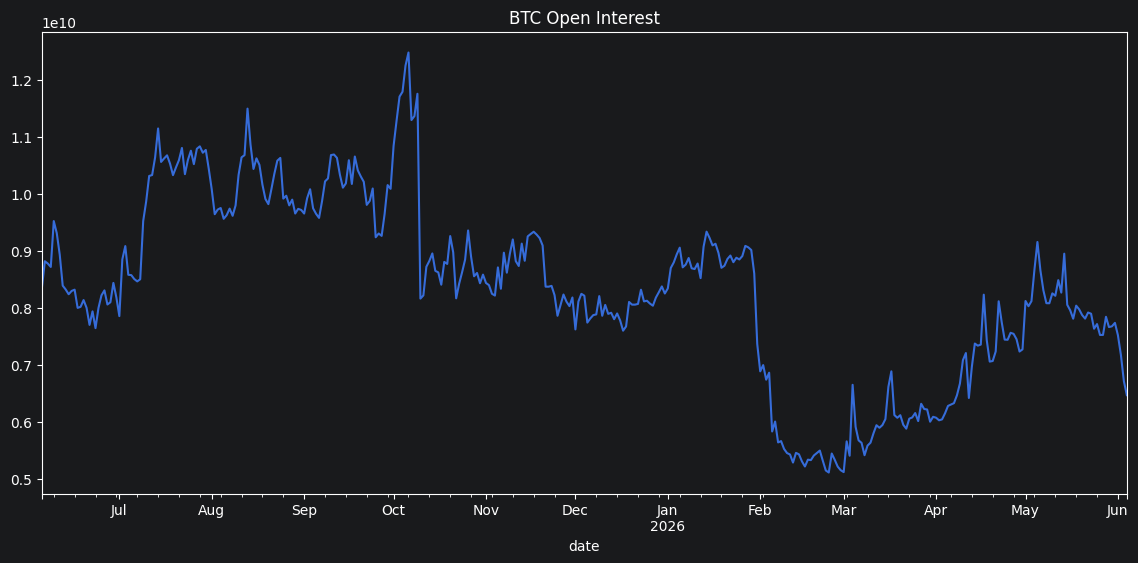

In [3497]:
# Open Interest Charts

prices['oi_close'].plot(figsize=(14,6))
plt.title('BTC Open Interest')
plt.show()

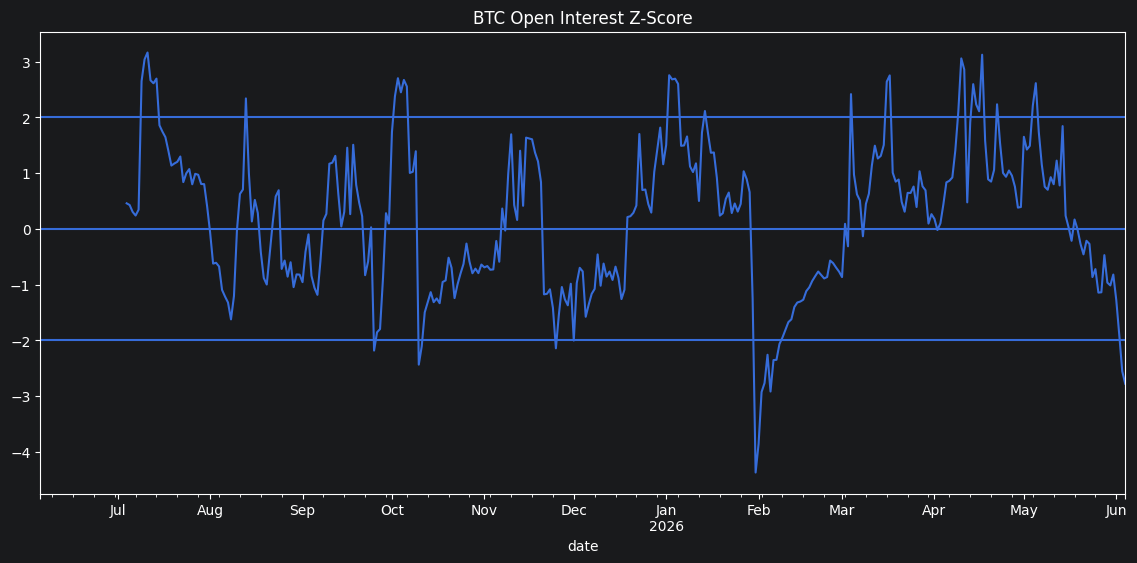

In [3498]:
prices['oi_zscore'].plot(figsize=(14,6))
plt.axhline(0)
plt.axhline(2)
plt.axhline(-2)
plt.title('BTC Open Interest Z-Score')
plt.show()

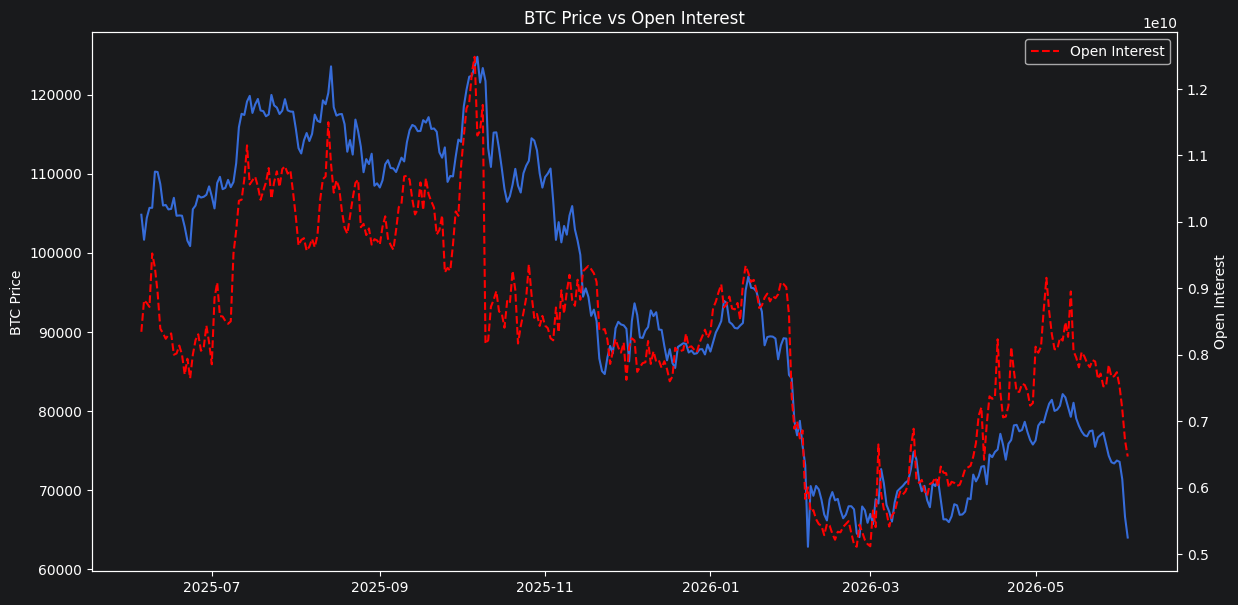

In [3499]:
fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(prices.index, prices['price'], label='BTC Price')
ax1.set_ylabel('BTC Price')

ax2 = ax1.twinx()

ax2.plot(prices.index, prices['oi_close'], linestyle='--', label='Open Interest', color='red')
ax2.set_ylabel('Open Interest')

plt.title('BTC Price vs Open Interest')
plt.legend()
plt.show()

In [3500]:
# 4. Build positioning regimes

prices['leverage_signal'] = 'Neutral'

In [3501]:
# Aggressive Long Buildup
prices.loc[
    (prices['7d_return'] > 0.03) &
    (prices['funding_zscore'] > 0.5) &
    (prices['oi_7d_change'] > 0),
    'leverage_signal'
] = 'Aggressive Long Buildup'

# Short Covering Rally
prices.loc[
    (prices['7d_return'] > 0.03) &
    (prices['oi_7d_change'] < 0),
    'leverage_signal'
] = 'Short Covering Rally'

#Aggressive Short Buildup
prices.loc[
    (prices['7d_return'] < -0.03) &
    (prices['funding_zscore'] < -0.5) &
    (prices['oi_7d_change'] > 0),
    'leverage_signal'
] = 'Aggressive Short Buildup'

# Long Liquidation
prices.loc[
    (prices['7d_return'] < -0.07) &
    (prices['oi_7d_change'] < 0),
    'leverage_signal'
] = 'Long Liquidation'

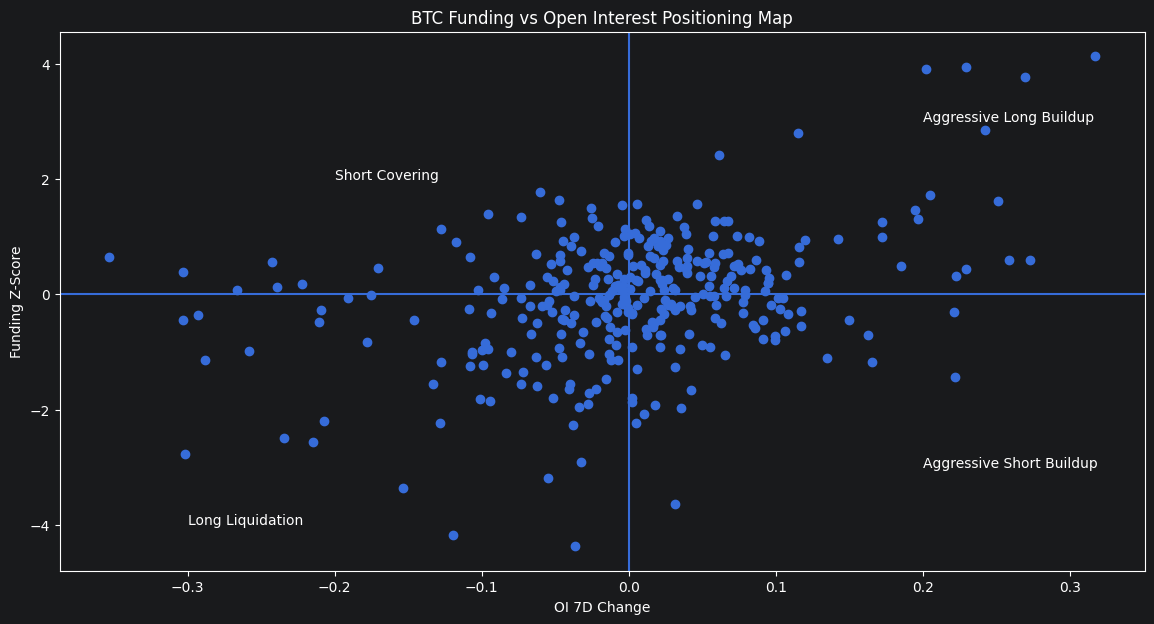

In [3502]:
# Funding z-score vs OI 7D change scatter

plt.figure(figsize=(14,7))

plt.scatter(prices['oi_7d_change'], prices['funding_zscore'])

plt.axhline(0)
plt.axvline(0)

# Quadrant Labels
plt.text(0.2, 3, 'Aggressive Long Buildup')
plt.text(0.2, -3, 'Aggressive Short Buildup')
plt.text(-0.2, 2, 'Short Covering')
plt.text(-0.3, -4, 'Long Liquidation')

plt.xlabel('OI 7D Change')
plt.ylabel('Funding Z-Score')
plt.title('BTC Funding vs Open Interest Positioning Map')

plt.show()

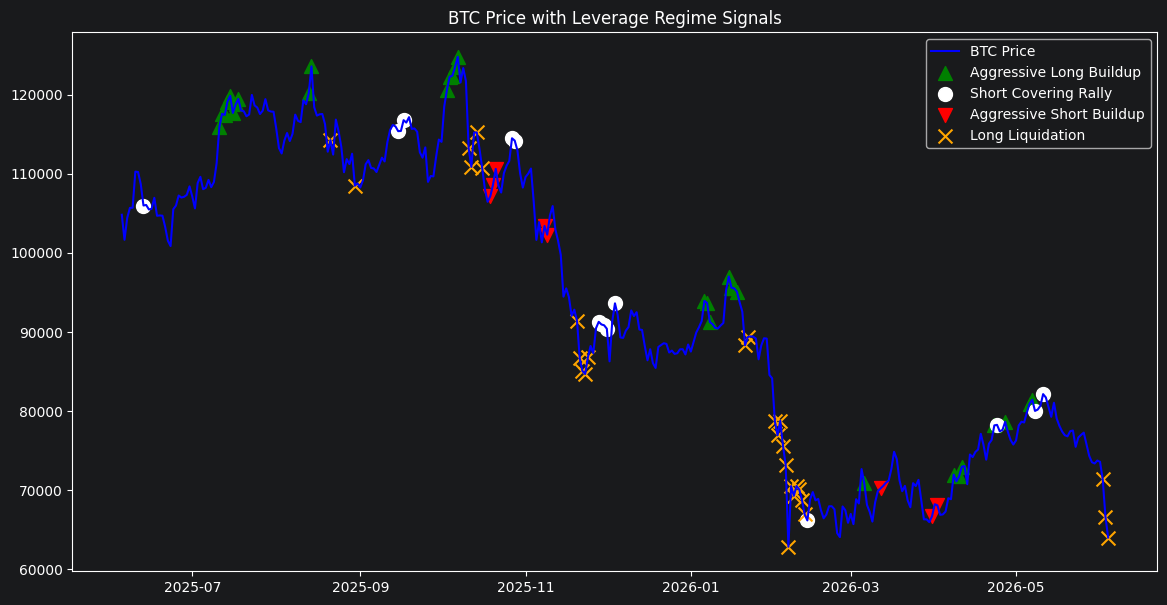

In [3503]:
# BTC Price with Leverage Regime Signals

long_buildup = prices[prices['leverage_signal'] == 'Aggressive Long Buildup']
short_covering = prices[prices['leverage_signal'] == 'Short Covering Rally']
short_buildup = prices[prices['leverage_signal'] == 'Aggressive Short Buildup']
long_liquidation = prices[prices['leverage_signal'] == 'Long Liquidation']

plt.figure(figsize=(14,7))

plt.plot(prices.index, prices['price'], label='BTC Price', color='blue')

plt.scatter(long_buildup.index, long_buildup['price'], label='Aggressive Long Buildup', marker='^', color='green', s=100)

plt.scatter(short_covering.index, short_covering['price'], label='Short Covering Rally', marker='o', color='white', s=100)

plt.scatter(short_buildup.index, short_buildup['price'], label='Aggressive Short Buildup', marker='v', color='red', s=100)

plt.scatter(long_liquidation.index, long_liquidation['price'], label='Long Liquidation', marker='x', color='orange', s=100)

plt.title('BTC Price with Leverage Regime Signals')
plt.legend()
plt.savefig(
    '../outputs/charts/leverage_regime_signals.png',
    bbox_inches='tight',
    dpi=300
)
plt.show()

In [3504]:
# 5. Pull BTC ETF flow data

etf_flow_url = (
    "https://open-api-v4.coinglass.com"
    "/api/etf/bitcoin/flow-history"
)

headers = {
    "accept": "application/json",
    "CG-API-KEY": os.getenv("COINGLASS_API_KEY")
}

response = requests.get(
    etf_flow_url,
    headers=headers
)

etf_flow_data = response.json()

In [3505]:
etf_flows = pd.DataFrame(etf_flow_data['data'])

etf_flows['timestamp'] = pd.to_datetime(
    etf_flows['timestamp'],
    unit='ms',
    utc=True
)

etf_flows = etf_flows.rename(columns={
    'timestamp':'date',
    'flow_usd':'btc_etf_flow_usd',
    'price_usd':'btc_etf_price_usd'
})

etf_flows = etf_flows[
    ['date', 'btc_etf_flow_usd', 'btc_etf_price_usd']
]

etf_flows = etf_flows.set_index('date')

In [3506]:
# ETF Flow Metrics

etf_flows['btc_etf_flow_7d'] = etf_flows['btc_etf_flow_usd'].rolling(7).sum()
etf_flows['btc_etf_flow_30d'] = etf_flows['btc_etf_flow_usd'].rolling(30).sum()

In [3507]:
etf_flow_mean = etf_flows['btc_etf_flow_usd'].rolling(30).mean()
etf_flow_std = etf_flows['btc_etf_flow_usd'].rolling(30).std()

etf_flows['btc_etf_flow_zscore'] = (etf_flows['btc_etf_flow_usd'] - etf_flow_mean) / etf_flow_std

In [3508]:
# Filter dataset for trailing 365 days

cutoff_date = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=365)

etf_flows_recent = etf_flows[
    etf_flows.index >= cutoff_date
].copy()

In [3509]:
print(etf_flows.tail())

                           btc_etf_flow_usd  btc_etf_price_usd  \
date                                                             
2026-05-29 00:00:00+00:00      -125300000.0            73591.4   
2026-06-01 00:00:00+00:00      -483800000.0            73653.2   
2026-06-02 00:00:00+00:00      -519100000.0            71391.5   
2026-06-03 00:00:00+00:00      -396600000.0            66730.1   
2026-06-04 00:00:00+00:00               0.0            64117.7   

                           btc_etf_flow_7d  btc_etf_flow_30d  \
date                                                           
2026-05-29 00:00:00+00:00    -1.692200e+09     -1.385400e+09   
2026-06-01 00:00:00+00:00    -2.105500e+09     -2.533100e+09   
2026-06-02 00:00:00+00:00    -2.523700e+09     -3.290600e+09   
2026-06-03 00:00:00+00:00    -2.815100e+09     -3.699000e+09   
2026-06-04 00:00:00+00:00    -2.481500e+09     -4.034800e+09   

                           btc_etf_flow_zscore  
date                                   

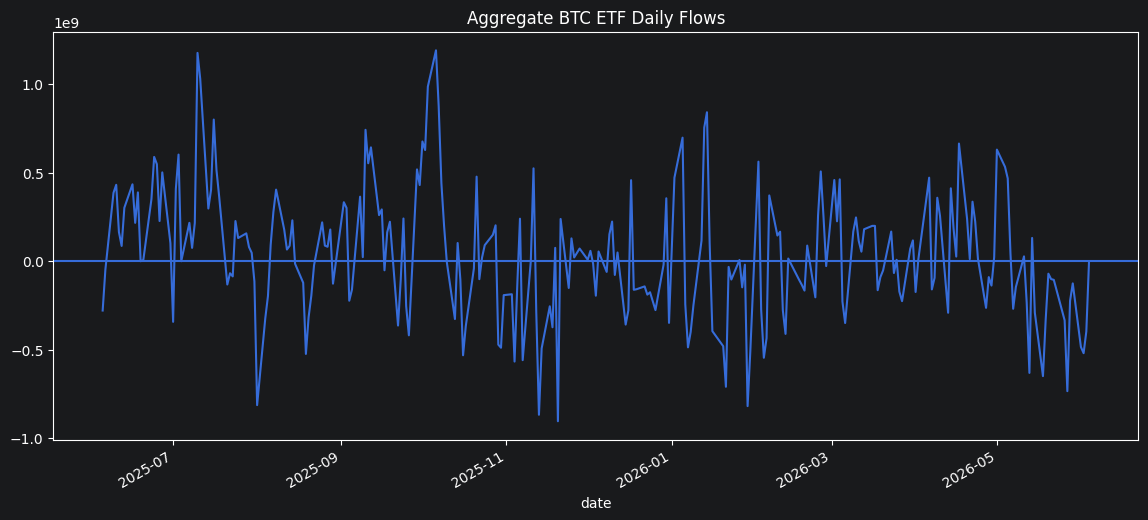

In [3510]:
# Visualize ETF Flows

etf_flows_recent['btc_etf_flow_usd'].plot(figsize=(14,6))
plt.axhline(0)
plt.title('Aggregate BTC ETF Daily Flows')
plt.show()

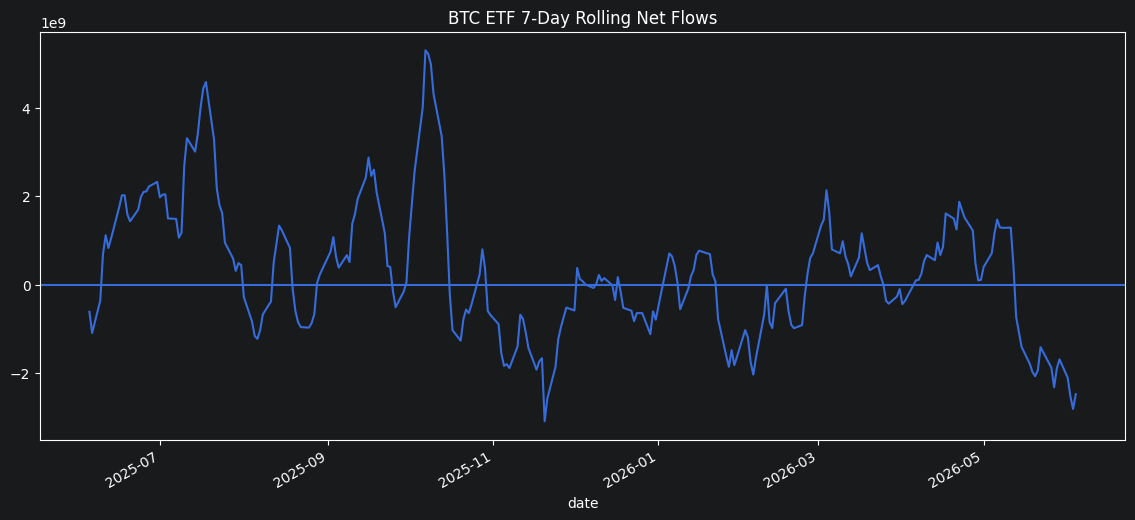

In [3511]:
etf_flows_recent['btc_etf_flow_7d'].plot(figsize=(14,6))
plt.axhline(0)
plt.title('BTC ETF 7-Day Rolling Net Flows')
plt.savefig(
    '../outputs/charts/rolling_etf_flows.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

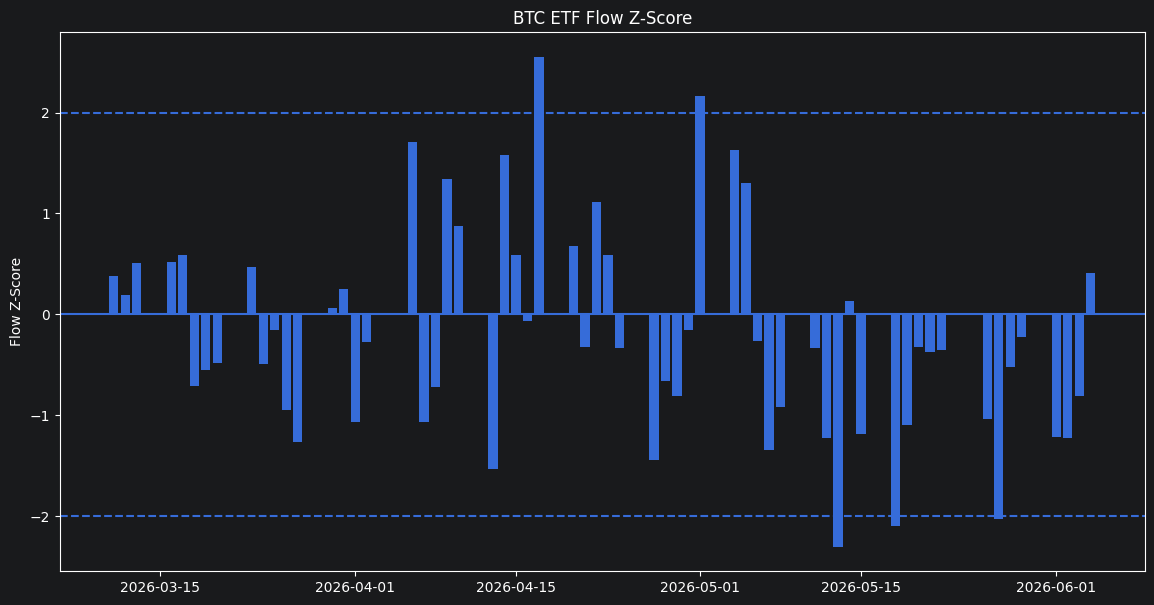

In [3512]:
# Recent ETF Flow Z-Scores

recent_flows = etf_flows_recent[['btc_etf_flow_zscore']].tail(60)

plt.figure(figsize=(14,7))

plt.bar(recent_flows.index, recent_flows['btc_etf_flow_zscore'])

plt.axhline(0)
plt.axhline(2, linestyle='--')
plt.axhline(-2, linestyle='--')

plt.title('BTC ETF Flow Z-Score')
plt.ylabel('Flow Z-Score')
plt.savefig(
    '../outputs/charts/etf_flow_zscore.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

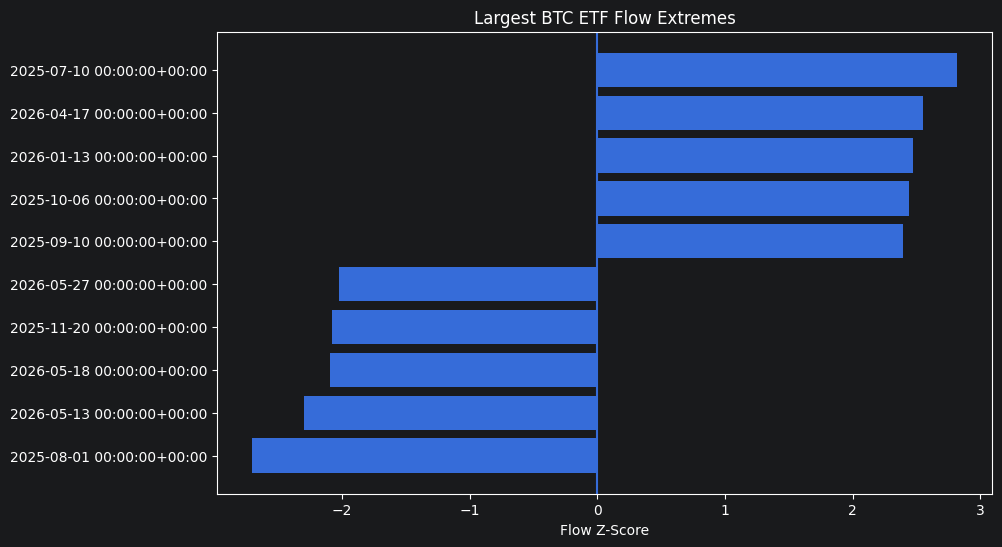

In [3513]:
# Largest Positive/Negative Flow Days

extreme_flows = etf_flows_recent[['btc_etf_flow_zscore']].dropna().sort_values(by='btc_etf_flow_zscore')

extreme_flows = pd.concat([
    extreme_flows.head(5),
    extreme_flows.tail(5)
])

plt.figure(figsize=(10,6))

plt.barh(extreme_flows.index.astype(str), extreme_flows['btc_etf_flow_zscore'])

plt.axvline(0)
plt.title('Largest BTC ETF Flow Extremes')
plt.xlabel('Flow Z-Score')
plt.show()

In [3514]:
# Merge ETF flows into prices

prices = prices.merge(etf_flows_recent[
        ['btc_etf_flow_usd',
        'btc_etf_flow_7d',
        'btc_etf_flow_30d',
        'btc_etf_flow_zscore']],
    on='date', how='left', validate='one_to_one'
)

In [3515]:
# Shift ETF flow metrics for report-card alignment.
# Raw ETF columns remain unshifted for research/diagnostics.

prices['btc_etf_flow_usd_shifted'] = prices['btc_etf_flow_usd'].shift(1)
prices['btc_etf_flow_7d_shifted'] = prices['btc_etf_flow_7d'].shift(1)
prices['btc_etf_flow_30d_shifted'] = prices['btc_etf_flow_30d'].shift(1)
prices['btc_etf_flow_zscore_shifted'] = prices['btc_etf_flow_zscore'].shift(1)

In [3516]:
# Institutional Flow Regimes - Research Version
# Uses unshifted ETF flow z-score for forward-return analysis.

prices['institutional_signal_research'] = 'Neutral'

prices.loc[
    prices['btc_etf_flow_zscore'] > 1.5,
    'institutional_signal_research'
] = 'Strong Institutional Inflows'

prices.loc[
    prices['btc_etf_flow_zscore'] < -1.5,
    'institutional_signal_research'
] = 'Institutional Outflows'

In [3517]:
# Institutional Flow Regimes

prices['institutional_signal'] = 'Neutral'

prices.loc[
    prices['btc_etf_flow_zscore_shifted'] > 1.5,
    'institutional_signal'
] = 'Strong Institutional Inflows'

prices.loc[
    prices['btc_etf_flow_zscore_shifted'] < -1.5,
    'institutional_signal'
] = 'Institutional Outflows'

In [3518]:
# Plotting Market Drivers

# Start Neutral
prices['market_driver'] = 'Neutral'

# Lowest priority first
prices.loc[
    (prices['institutional_signal'] == 'Strong Institutional Inflows') &
    (prices['leverage_signal'] == 'Neutral'),
    'market_driver'
] = 'Spot-Led Institutional Demand'

prices.loc[
    (prices['institutional_signal'] == 'Neutral') &
    (prices['leverage_signal'] == 'Aggressive Long Buildup'),
    'market_driver'
] = 'Leverage-Driven Rally'

# Higher priority
prices.loc[
    (prices['institutional_signal'] == 'Strong Institutional Inflows') &
    (prices['leverage_signal'] == 'Aggressive Long Buildup'),
    'market_driver'
] = 'Institutional + Leverage Momentum'

# Highest priority LAST
prices.loc[
    (prices['institutional_signal'] == 'Institutional Outflows') |
    (prices['leverage_signal'] == 'Long Liquidation'),
    'market_driver'
] = 'Risk-Off / Deleveraging'

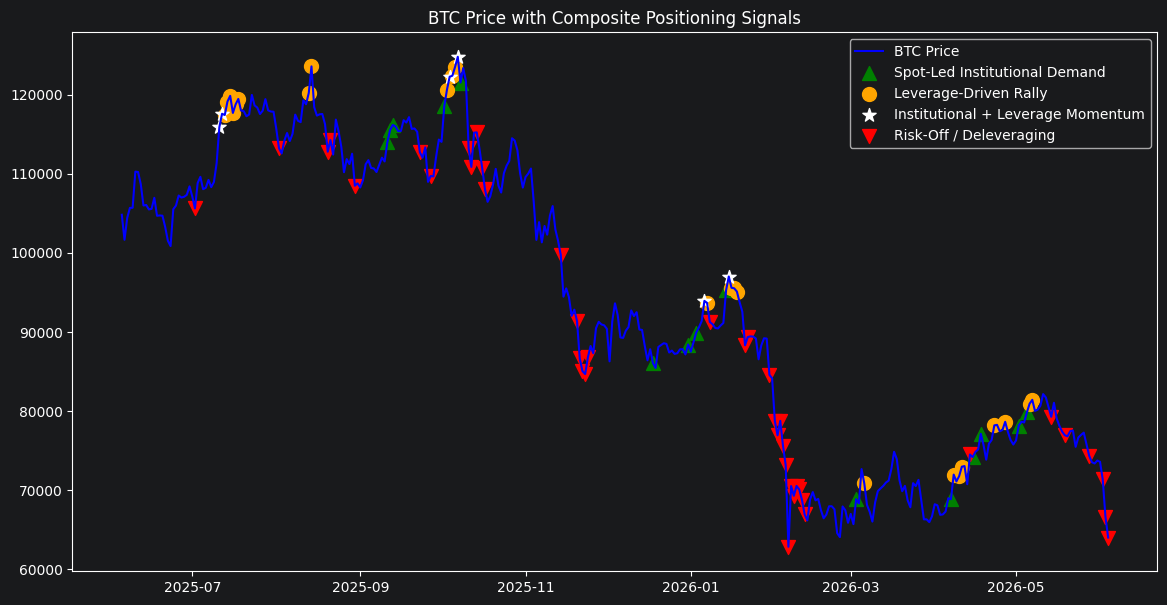

In [3519]:
signal_df = prices[prices['market_driver'] != 'Neutral']

plt.figure(figsize=(14,7))

plt.plot(prices.index, prices['price'], color='blue', label='BTC Price')

marker_map = {
    'Spot-Led Institutional Demand': ('^', 'green'),
    'Leverage-Driven Rally': ('o', 'orange'),
    'Institutional + Leverage Momentum': ('*', 'white'),
    'Risk-Off / Deleveraging': ('v', 'red')
}

for signal, (marker, color) in marker_map.items():
    subset = signal_df[signal_df['market_driver'] == signal]

    plt.scatter(
        subset.index,
        subset['price'],
        label=signal,
        marker=marker,
        color=color,
        s=100
    )

plt.title('BTC Price with Composite Positioning Signals')
plt.legend()
plt.savefig(
    '../outputs/charts/composite_positioning_signals.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [3520]:
# 6. Pull BTC liquidation data

liquidation_url = (
    "https://open-api-v4.coinglass.com"
    "/api/futures/liquidation/aggregated-history"
)

headers = {
    "accept": "application/json",
    "CG-API-KEY": os.getenv("COINGLASS_API_KEY")
}

params = {
    "symbol": "BTC",
    "interval": "1d",
    "exchange_list": "Binance"
}

response = requests.get(
    liquidation_url,
    headers=headers,
    params=params
)

response.raise_for_status()

liquidation_data = response.json()

In [3521]:
liquidations = pd.DataFrame(liquidation_data['data'])

liquidations['time'] = pd.to_datetime(liquidations['time'], unit='ms', utc=True)

liquidations = liquidations.rename(columns={
    'time':'date',
    'aggregated_long_liquidation_usd':'long_liquidations_usd',
    'aggregated_short_liquidation_usd':'short_liquidations_usd'
})

liquidations = liquidations[
    [
        'date',
        'long_liquidations_usd',
        'short_liquidations_usd'
    ]
]

liquidations = liquidations.set_index('date')

liquidations['total_liquidations_usd'] = liquidations['long_liquidations_usd'] + liquidations['short_liquidations_usd']

In [3522]:
liquidations['long_liq_zscore'] = (liquidations['long_liquidations_usd'] - liquidations['long_liquidations_usd'].rolling(30).mean()) / liquidations['long_liquidations_usd'].rolling(30).std()
liquidations['short_liq_zscore'] = (liquidations['short_liquidations_usd'] - liquidations['short_liquidations_usd'].rolling(30).mean()) / liquidations['short_liquidations_usd'].rolling(30).std()

In [3523]:
# Filter dataset for trailing 365 days

cutoff_date = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=365)

liquidations_recent = liquidations[
    liquidations.index >= cutoff_date
].copy()

In [3524]:
prices = prices.merge(liquidations_recent, on='date', how='left', validate='one_to_one')

In [3525]:
prices['long_liq_zscore_shifted'] = (
    prices['long_liq_zscore']
    .shift(1)
)

prices['short_liq_zscore_shifted'] = (
    prices['short_liq_zscore']
    .shift(1)
)

In [3526]:
prices['liquidation_signal'] = 'Neutral'

prices.loc[
    (prices['long_liq_zscore_shifted'] > 1) &
    (prices['short_liq_zscore_shifted'] <= 1),
    'liquidation_signal'
] = 'Elevated Long Liquidation'

prices.loc[
    (prices['short_liq_zscore_shifted'] > 1) &
    (prices['long_liq_zscore_shifted'] <= 1),
    'liquidation_signal'
] = 'Elevated Short Liquidation'

prices.loc[
    (prices['long_liq_zscore_shifted'] > 1) &
    (prices['short_liq_zscore_shifted'] > 1),
    'liquidation_signal'
] = 'Two-Sided Liquidation Event'

In [3527]:
prices['liquidation_signal_research'] = 'Neutral'

prices.loc[
    (prices['long_liq_zscore'] > 1) &
    (prices['short_liq_zscore'] <= 1),
    'liquidation_signal_research'
] = 'Elevated Long Liquidation'

prices.loc[
    (prices['short_liq_zscore'] > 1) &
    (prices['long_liq_zscore'] <= 1),
    'liquidation_signal_research'
] = 'Elevated Short Liquidation'

prices.loc[
    (prices['long_liq_zscore'] > 1) &
    (prices['short_liq_zscore'] > 1),
    'liquidation_signal_research'
] = 'Two-Sided Liquidation Event'

In [3542]:
elevated_long_liq = prices[prices['liquidation_signal_research'] == 'Elevated Long Liquidation']
elevated_short_liq = prices[prices['liquidation_signal_research'] == 'Elevated Short Liquidation']
two_sided_liq = prices[prices['liquidation_signal_research'] == 'Two-Sided Liquidation Event']

In [3543]:
# Refine Market Driver with Liquidation Confirmation

prices.loc[
    (prices['market_driver'] == 'Risk-Off / Deleveraging') &
    (prices['liquidation_signal'] == 'Elevated Long Liquidation'),
    'market_driver'
] = 'Risk-Off / Forced Deleveraging'

prices.loc[
    (prices['market_driver'] == 'Leverage-Driven Rally') &
    (prices['liquidation_signal'] == 'Elevated Short Liquidation'),
    'market_driver'
] = 'Short Squeeze / Forced Buying'

In [3544]:
# 6. Run conditional forward-return analysis

prices['forward_7d_return'] = (prices['price'].shift(-7) / prices['price']) - 1
prices['forward_30d_return'] = (prices['price'].shift(-30) / prices['price']) - 1

In [3545]:
# Forward return subset for ETF inflow research
strong_etf_inflows = prices[
    prices['institutional_signal_research'] == 'Strong Institutional Inflows'
]

In [3546]:
# What Happens after Aggressive Long Buildup?
long_buildup = prices[prices['leverage_signal'] == 'Aggressive Long Buildup']

In [3547]:
# Long Liquidation
long_liquidation = prices[prices['leverage_signal'] == 'Long Liquidation']

In [3548]:
# Short Buildup
short_buildup = prices[prices['leverage_signal'] == 'Aggressive Short Buildup']

In [3549]:
# Short Covering
short_covering = prices[prices['leverage_signal'] == 'Short Covering Rally']

In [3550]:
etf_median = strong_etf_inflows[['forward_7d_return', 'forward_30d_return']].median()
long_median = long_buildup[['forward_7d_return', 'forward_30d_return']].median()
long_liquidation_median = long_liquidation[['forward_7d_return', 'forward_30d_return']].median()
short_buildup_median = short_buildup[['forward_7d_return', 'forward_30d_return']].median()
short_covering_median = short_covering[['forward_7d_return', 'forward_30d_return']].median()

print(
    f"Strong ETF Inflows | "
    f"Median 7D: {etf_median['forward_7d_return']:.2%} | "
    f"Median 30D: {etf_median['forward_30d_return']:.2%}"
)

print(
    f"Aggressive Long Buildup | "
    f"Median 7D: {long_median['forward_7d_return']:.2%} | "
    f"Median 30D: {long_median['forward_30d_return']:.2%}"
)

print(
    f"Aggressive Long Liquidation | "
    f"Median 7D: {long_liquidation_median['forward_7d_return']:.2%} | "
    f"Median 30D: {long_liquidation_median['forward_30d_return']:.2%}"
)

print(
    f"Aggressive Short Buildup | "
    f"Median 7D: {short_buildup_median['forward_7d_return']:.2%} | "
    f"Median 30D: {short_buildup_median['forward_30d_return']:.2%}"
)

print(
    f"Short Covering Rally | "
    f"Median 7D: {short_covering_median['forward_7d_return']:.2%} | "
    f"Median 30D: {short_covering_median['forward_30d_return']:.2%}"
)

Strong ETF Inflows | Median 7D: 2.00% | Median 30D: -3.67%
Aggressive Long Buildup | Median 7D: -1.24% | Median 30D: -4.47%
Aggressive Long Liquidation | Median 7D: -1.88% | Median 30D: -3.57%
Aggressive Short Buildup | Median 7D: 3.24% | Median 30D: -12.10%
Short Covering Rally | Median 7D: -1.74% | Median 30D: -3.62%


In [3551]:
# Summary of Signals

signal_summary = pd.DataFrame({
    'signal': [
        'Strong ETF Inflows',
        'Aggressive Long Buildup',
        'Long Liquidation',
        'Aggressive Short Buildup',
        'Short Covering Rally',
        'Elevated Long Liquidation',
        'Elevated Short Liquidation'
    ],
    'obs_7d': [
        strong_etf_inflows['forward_7d_return'].count(),
        long_buildup['forward_7d_return'].count(),
        long_liquidation['forward_7d_return'].count(),
        short_buildup['forward_7d_return'].count(),
        short_covering['forward_7d_return'].count(),
        elevated_long_liq['forward_7d_return'].count(),
        elevated_short_liq['forward_7d_return'].count()
    ],
    'obs_30d': [
        strong_etf_inflows['forward_30d_return'].count(),
        long_buildup['forward_30d_return'].count(),
        long_liquidation['forward_30d_return'].count(),
        short_buildup['forward_30d_return'].count(),
        short_covering['forward_30d_return'].count(),
        elevated_long_liq['forward_30d_return'].count(),
        elevated_short_liq['forward_30d_return'].count()
    ],
    'median_7d_return': [
        strong_etf_inflows['forward_7d_return'].median(),
        long_buildup['forward_7d_return'].median(),
        long_liquidation['forward_7d_return'].median(),
        short_buildup['forward_7d_return'].median(),
        short_covering['forward_7d_return'].median(),
        elevated_long_liq['forward_7d_return'].median(),
        elevated_short_liq['forward_7d_return'].median()
    ],
    'median_30d_return': [
        strong_etf_inflows['forward_30d_return'].median(),
        long_buildup['forward_30d_return'].median(),
        long_liquidation['forward_30d_return'].median(),
        short_buildup['forward_30d_return'].median(),
        short_covering['forward_30d_return'].median(),
        elevated_long_liq['forward_30d_return'].median(),
        elevated_short_liq['forward_30d_return'].median()
    ]
})

In [3552]:
signal_summary_raw = signal_summary.copy()
signal_summary_display = signal_summary.copy()

In [3553]:
signal_summary_display = signal_summary_display.sort_values('median_7d_return', ascending=False).reset_index(drop=True)

signal_summary_display['median_7d_return'] = signal_summary_display['median_7d_return'].map('{:.2%}'.format)
signal_summary_display['median_30d_return'] = signal_summary_display['median_30d_return'].map('{:.2%}'.format)

print(signal_summary_display)

                       signal  obs_7d  obs_30d median_7d_return  \
0    Aggressive Short Buildup       8        8            3.24%   
1  Elevated Short Liquidation      39       39            2.29%   
2          Strong ETF Inflows      22       22            2.00%   
3     Aggressive Long Buildup      30       28           -1.24%   
4        Short Covering Rally      14       12           -1.74%   
5            Long Liquidation      25       25           -1.88%   
6   Elevated Long Liquidation      36       29           -3.13%   

  median_30d_return  
0           -12.10%  
1             0.91%  
2            -3.67%  
3            -4.47%  
4            -3.62%  
5            -3.57%  
6            -2.53%  


In [3554]:
# 7. BTC Daily Positioning Report

latest = prices.iloc[-1]
latest_date = prices.index[-1]

In [3555]:
report_date = pd.Timestamp.today().date()
market_date = (latest_date - pd.Timedelta(days=1)).date()

print("BTC DAILY POSITIONING REPORT")
print("-" * 35)
print(f"Generated: {report_date}")
print(f"Market Data Through: {market_date}")

print("\nPRICE")
print(f"BTC Price: ${latest['price']:,.0f}")
print(f"1D Return: {latest['daily_return']:.1%}")
print(f"7D Return: {latest['7d_return']:.1%}")
print(f"30D Return: {latest['30d_return']:.1%}")
print(f"Rolling 7D Volatility: {latest['rolling_vol_7d']:.1%}")

print("\nINSTITUTIONAL DEMAND")
print(f"ETF Flow Z-Score: {latest['btc_etf_flow_zscore_shifted']:.1f}")
print(f"Institutional Signal: {latest['institutional_signal']}")

print("\nLEVERAGE POSITIONING")
print(f"Funding Z-Score: {latest['funding_zscore']:.1f}")
print(f"OI Z-Score: {latest['oi_zscore']:.1f}")
print(f"OI 7D Change: {latest['oi_7d_change']:.1%}")
print(f"Leverage Signal: {latest['leverage_signal']}")

print("\nLIQUIDATION ACTIVITY")
print(f"Long Liquidation Z-Score: {latest['long_liq_zscore_shifted']:.1f}")
print(f"Short Liquidation Z-Score: {latest['short_liq_zscore_shifted']:.1f}")
print(f"Liquidation Signal: {latest['liquidation_signal']}")

print("\nPRIMARY MARKET REGIME IDENTIFICATION")
print(f"{latest['market_driver']}")

print("\nINTERPRETATION")

# Market driver first
if latest['market_driver'] == 'Risk-Off / Deleveraging':
    print("- Positioning data indicates a risk-off / deleveraging environment.")

elif latest['market_driver'] == 'Institutional + Leverage Momentum':
    print("- Institutional inflows and leverage expansion are both supporting upside momentum.")

elif latest['market_driver'] == 'Spot-Led Institutional Demand':
    print("- Price action appears more institutionally supported than leverage-driven.")

elif latest['market_driver'] == 'Leverage-Driven Rally':
    print("- Rally appears more leverage-driven; watch for crowding risk.")

else:
    print("- No major composite positioning regime currently detected.")

# Institutional signal
if latest['institutional_signal'] == 'Strong Institutional Inflows':
    print("- ETF inflows indicate strong institutional demand, supporting the spot market.")

elif latest['institutional_signal'] == 'Institutional Outflows':
    print("- ETF outflows indicate institutional selling pressure, reinforcing the spot move lower.")

elif latest['institutional_signal'] == 'Neutral':
    print("- ETF flows were neutral, suggesting institutional demand was not the primary driver.")

# Leverage signal
if latest['leverage_signal'] == 'Aggressive Long Buildup':
    print(
        f"- Rising prices and an OI Z-score of {latest['oi_zscore']:.1f} suggest new leveraged long exposure entering the market."
    )

elif latest['leverage_signal'] == 'Aggressive Short Buildup':
    print(
        f"- Falling prices and an OI Z-score of {latest['oi_zscore']:.1f} suggest new short positioning entering the market."
    )

elif latest['leverage_signal'] == 'Short Covering Rally':
    print(
        f"- Price strength alongside an OI Z-score of {latest['oi_zscore']:.1f} suggests short positions may be covering."
    )

elif latest['leverage_signal'] == 'Long Liquidation':
    print(
        f"- BTC fell {latest['daily_return']:.1%} while open interest reached a "
        f"{latest['oi_zscore']:.1f} Z-score, consistent with long positioning being unwound."
    )

# Liquidation signal
if latest['liquidation_signal'] == 'Elevated Long Liquidation':
    print("- Elevated long liquidations indicate forced selling pressure from leveraged longs.")

elif latest['liquidation_signal'] == 'Elevated Short Liquidation':
    print("- Short liquidation activity is elevated, suggesting squeeze dynamics.")

elif latest['liquidation_signal'] == 'Two-Sided Liquidation Event':
    print("- Both long and short liquidations are elevated, suggesting a high-volatility liquidation event.")

BTC DAILY POSITIONING REPORT
-----------------------------------
Generated: 2026-06-04
Market Data Through: 2026-06-03

PRICE
BTC Price: $64,022
1D Return: -3.9%
7D Return: -13.9%
30D Return: -19.8%
Rolling 7D Volatility: 2.6%

INSTITUTIONAL DEMAND
ETF Flow Z-Score: -0.8
Institutional Signal: Neutral

LEVERAGE POSITIONING
Funding Z-Score: -0.0
OI Z-Score: -2.8
OI 7D Change: -17.5%
Leverage Signal: Long Liquidation

LIQUIDATION ACTIVITY
Long Liquidation Z-Score: 1.1
Short Liquidation Z-Score: 0.0
Liquidation Signal: Elevated Long Liquidation

PRIMARY MARKET REGIME IDENTIFICATION
Risk-Off / Forced Deleveraging

INTERPRETATION
- No major composite positioning regime currently detected.
- ETF flows were neutral, suggesting institutional demand was not the primary driver.
- BTC fell -3.9% while open interest reached a -2.8 Z-score, consistent with long positioning being unwound.
- Elevated long liquidations indicate forced selling pressure from leveraged longs.


In [3556]:
# ETF flows and liquidation data are shifted by one day.
# CoinGecko prices represent a daily snapshot at 00:00 UTC,
# while ETF flows and liquidation totals represent activity
# occurring throughout the prior trading day.
# Shifting aligns activity-based metrics with the subsequent
# price observation used in the positioning report.